# Cancer Classification Using The Cancer Genome Atlas (TCGA)

## 1. Data Pre-Processing

In [6]:
# Load relevant libraries
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

# Imbalanced data
from imblearn.over_sampling import SMOTE

# Label noise detection
from cleanlab.filter import find_label_issues

# Evaluation
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score)

# Misc
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [8]:
# Load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst few rows of train:")
train.head()

Train shape: (886, 12044)
Test shape: (379, 12043)

First few rows of train:


,id,cancer,RNF14,UBE2Q1,RNF17,RNF10,RNF11,RNF13,REM1,TSKS,...,SELE,SLC7A10,SLC7A11,FOLR1,NPY5R,GNGT1,PTRF,SERPINH1,NFIX,SELP
0,S8886438,1,8.130644,8.869802,4.355382,6.882796,9.170429,9.695898,4.609017,4.123772,...,3.884740,4.363119,5.565958,3.951505,3.849734,4.209866,8.519448,7.921267,5.662386,4.152534
1,S1818761,3,5.502858,8.791778,3.729482,6.556056,8.262384,7.596577,4.263336,3.008913,...,2.917661,3.249593,4.446910,9.439381,3.248632,3.221614,6.413054,8.645957,3.475170,3.074514
2,S2937758,1,7.537196,9.220189,4.354501,7.368029,9.307845,8.833408,4.707772,3.909128,...,3.837739,4.129411,5.789456,4.037472,3.716405,3.828743,7.160989,7.874510,5.672849,4.426313
3,S3008005,3,7.014867,9.453761,3.702113,5.985680,9.008926,7.947574,5.470811,3.107538,...,2.709770,3.438689,6.110492,8.970555,3.229985,3.367337,4.686543,7.726071,3.387412,3.314188
4,S2869276,1,8.169815,9.402682,4.062033,7.555819,9.717518,10.628858,4.926767,3.746619,...,3.483991,3.734450,6.275364,4.134837,3.966953,3.450866,7.012476,7.292837,7.488271,4.061273


In [10]:
print("Train columns:", train.columns[:10].tolist(), "...")  # first 10
print("\nMissing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

print("\nClass distribution:")
train['cancer'].value_counts().to_frame()

Train columns: ['id', 'cancer', 'RNF14', 'UBE2Q1', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'REM1', 'TSKS'] ...

Missing values in train: 0
Missing values in test: 0

Class distribution:


,count
cancer,
3,408
1,348
2,130


The data contains 886 samples: 408 GBM (3), 130 LUSC (2) and 420 OV (1). Observe there are no missing values either in the test or in the train data. The test data contains 379 unlabelled samples (that's why there's one column less).

In [12]:
# Separate features and labels.
X_train = train.drop(columns=['cancer', 'id'])  # adjust 'sample_id' to actual column name
y_train = train['cancer']

## 2. Exploratory Data Analysis

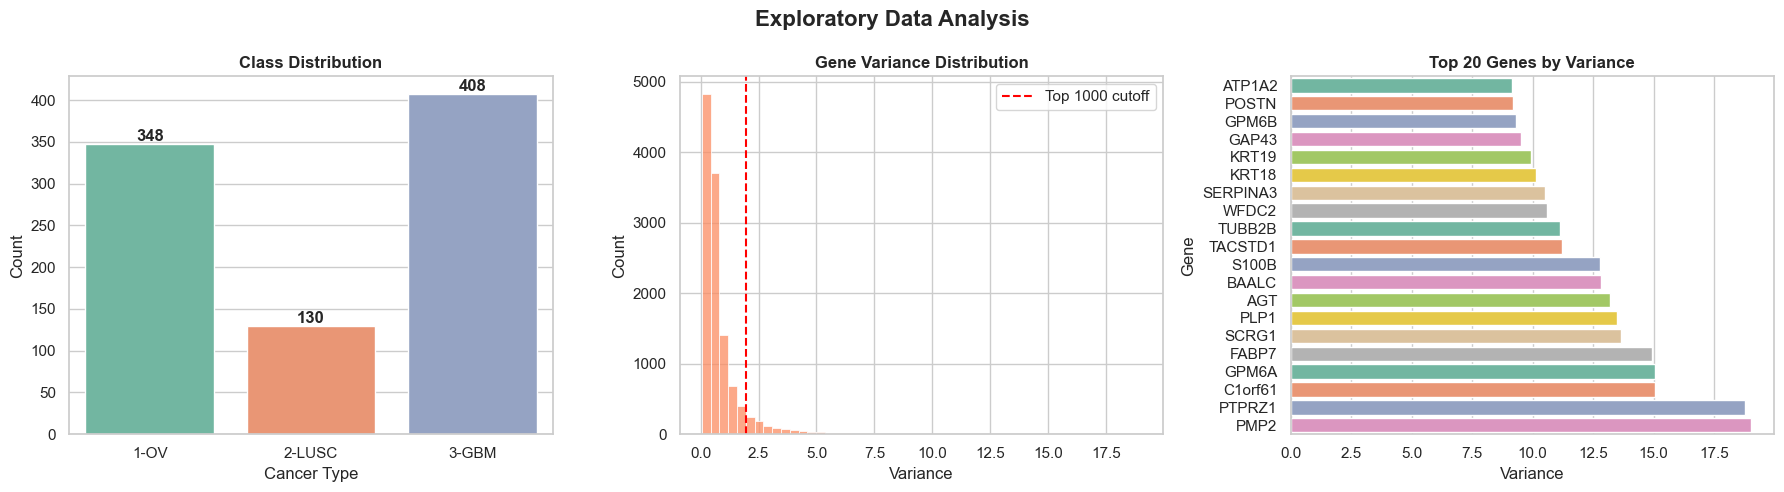

In [14]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Class Distribution
label_map = {1: '1-OV', 2: '2-LUSC', 3: '3-GBM'}
class_counts = y_train.value_counts().sort_index().reset_index()
class_counts.columns = ['Cancer Type', 'Count']
class_counts['Cancer Type'] = class_counts['Cancer Type'].map(label_map)
sns.barplot(data=class_counts, x='Cancer Type', y='Count', palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution', fontweight='bold')
for i, val in enumerate(class_counts['Count']):
    axes[0].text(i, val + 3, str(val), ha='center', fontweight='bold')

# Plot 2: Gene Variance Distribution
gene_variances = X_train.var(axis=0)
sns.histplot(gene_variances, bins=50, color=sns.color_palette('Set2')[1], ax=axes[1])
axes[1].set_title('Gene Variance Distribution', fontweight='bold')
axes[1].set_xlabel('Variance')
axes[1].axvline(gene_variances.nlargest(1000).min(), color='red', linestyle='--', label='Top 1000 cutoff')
axes[1].legend()

# Plot 3: Top 20 Genes by Variance
top20 = gene_variances.nlargest(20).sort_values().reset_index()
top20.columns = ['Gene', 'Variance']
sns.barplot(data=top20, x='Variance', y='Gene', palette='Set2', ax=axes[2])
axes[2].set_title('Top 20 Genes by Variance', fontweight='bold')

plt.tight_layout()
plt.show()

Plot 1: We observe the class imbalance among 

Plot 2: The massive bar near zero confirms that the vast majority of genes are not very informative as they barely change across patients. The red dashed line shows the top 500 cutoff at around variance = 3, meaning everything to the left of it gets dropped

Plot 3: We believe this plot depicts the most informative genes, the ones that vary the most across cancer types. **PMP2** and **PTPRZ1** stand out as by far the most variable. Interestingly, several of these are biologically meaningful — for example **PTPRZ1 is a known GBM marker**, and **PLP1, FABP7, SCRG1 are all associated with brain/neural tissue**, which makes sense given GBM is a brain cancer. **KRT18, KRT19, WFDC2 are associated with epithelial/ovarian tissue**, which aligns with OV.

## 3. Pipeline A: Variance Filtering + Random Forest

In [16]:
## Split the training data into test and validation sets.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2,
    stratify=y_train,
    random_state=16 #setting a seed
)

print("Training set:  ", X_tr.shape)
print("Validation set:", X_val.shape)
print("\nClass distribution in training set:")
print(y_tr.value_counts().sort_index())
print("\nClass distribution in validation set:")
print(y_val.value_counts().sort_index())

Training set:   (708, 12042)
Validation set: (178, 12042)

Class distribution in training set:
cancer
1    278
2    104
3    326
Name: count, dtype: int64

Class distribution in validation set:
cancer
1    70
2    26
3    82
Name: count, dtype: int64


The class distribution looks representative as we used stratified random sampling to maintain representativeness in both the test and train datasets. Also observe the training set will contain **708** observations, and the validation set will contain **178**.

### How many of the most variable genes should we include in our training set?

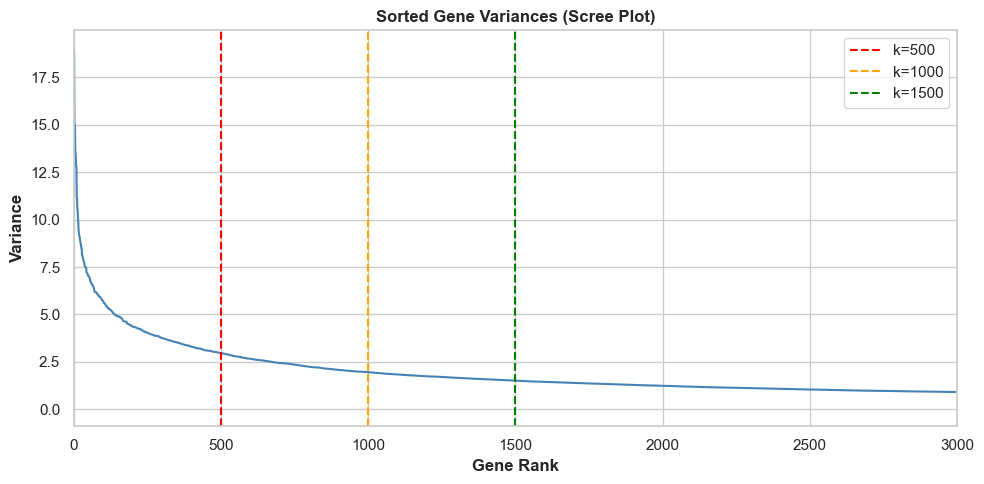

In [18]:
sorted_variances = gene_variances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, len(sorted_variances) + 1),
             y=sorted_variances.values, color='steelblue')
plt.xlabel('Gene Rank', fontweight='bold')
plt.ylabel('Variance', fontweight='bold')
plt.title('Sorted Gene Variances (Scree Plot)', fontweight='bold')
plt.xlim(0, 3000)
plt.axvline(500, color='red', linestyle='--', label='k=500')
plt.axvline(1000, color='orange', linestyle='--', label='k=1000')
plt.axvline(1500, color='green', linestyle='--', label='k=1500')
plt.legend()
plt.tight_layout()
plt.show()

We decided to go with the top **1000 most variable genes** based on the Scree Plot above.

In [20]:
# Now we select the 1000 top most variable genes from the TRAINING set to keep in our datasets.
gene_variances = X_tr.var(axis=0)
top_genes = gene_variances.nlargest(1000).index

X_tr_filtered = X_tr[top_genes]
X_val_filtered = X_val[top_genes]  # apply same genes, no recomputing!

In this step, we filtered genes in the training set by variance, and selected the top 1000 most variable genes to keep before training the random forest. Note that we also filtered these same genes on the validation set for later use to avoid data leakage (we only select from the training set).

!! Note that we will tune this number later through cross validation.

### Random Forest

We decided to use Random Forest, as it will reduce the variance compared to using bagging or a single decision tree. The key here is to select m < p predictors to consider at each split, rather than the full set of predictors. This helps reduce the correlation between trees, by randomly selecting a subset of the predictors in each split of buiding each single tree. The average will be much different than if each tree was split on the full set of predictors (it will select the most strong predictor each time and trees would be very similar).

In our case, we decided to tune the following parameters:
+ **m**: Number of predictors considered at each split (commonly m = √p, we will also consider p, corresponding to bagging, and p/2).
+ **nodesize**: This controls how deep the trees grow. A nodesize of 1 means trees grow until every leaf is pure (fully grown), while larger values force earlier stopping.

We will set **B = 1000**, which indicates the number of trees we want to fit. We decided on this number based on the study by Díaz-Uriarte & Alvarez de Andrés (2006), which examined forest sizes ranging from 1000 to 40,000 trees on multiple cancer genome data and found no differences in error rates.

Lastly, we will be using **OOB accuracy**, out-of-bag accuracy, to select the model parameters. This just measures the accuracy of the model on the roughly 30% of observations that were not used in training the tree as they were not selected into the boostrap samples.

In [31]:
# Step 1: Define grid
p = X_tr_filtered.shape[1]
sqrt_p = int(math.sqrt(p))   # ~32
half_p = p // 2              # 500

mtry_grid = sorted(set([sqrt_p, 10, 20, 30, 50, 75, 100, 150, half_p, p]))
mtry_grid = [m for m in mtry_grid if m <= p]
nodesize_grid = [1, 3, 5, 10]

print(f"p={p} | sqrt(p)={sqrt_p} | p/2={half_p}")
print(f"mtry grid: {mtry_grid}")

tuning_results = []

# Step 2: Tune via OOB
for mtry, nodesize in itertools.product(mtry_grid, nodesize_grid):
    rf = RandomForestClassifier(
        n_estimators=1000,
        max_features=mtry,
        min_samples_leaf=nodesize,
        max_depth=None,
        class_weight='balanced',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr_filtered, y_tr)
    
    oob_acc = rf.oob_score_
    oob_err = 1 - oob_acc
    
    # LUSC class error via OOB
    oob_preds = np.argmax(rf.oob_decision_function_, axis=1)
    lusc_mask = (y_tr.values == 2)
    lusc_error = 1 - np.mean(oob_preds[lusc_mask] == y_tr.values[lusc_mask])
    
    tuning_results.append({
        'mtry': mtry,
        'nodesize': nodesize,
        'OOB_Accuracy': round(oob_acc * 100, 2),
        'OOB_Error': round(oob_err, 4),
        'LUSC_Error': round(lusc_error * 100, 2)
    })
    
    print(f"mtry={mtry:>4} | nodesize={nodesize:>2} | OOB Acc={oob_acc*100:.2f}% | LUSC Error={lusc_error*100:.2f}%")

# Step 3: Results table
tuning_df = pd.DataFrame(tuning_results).sort_values('OOB_Accuracy', ascending=False).reset_index(drop=True)
print("\n--- Tuning Results (sorted by OOB Accuracy) ---")
print(tuning_df)

# Step 4: Best model ---
best_idx = tuning_df['OOB_Error'].idxmin()
best_params = tuning_df.loc[best_idx]
print(f"\nBest: mtry={int(best_params['mtry'])} | nodesize={int(best_params['nodesize'])} | OOB Acc={best_params['OOB_Accuracy']}%")

# Step 5: Refit best model
best_rf = RandomForestClassifier(
    n_estimators=1000,
    max_features=int(best_params['mtry']),
    min_samples_leaf=int(best_params['nodesize']),
    max_depth=None,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_tr_filtered, y_tr)

# Step 6: Confusion matrices
oob_preds = np.argmax(best_rf.oob_decision_function_, axis=1)
print("\nOOB Confusion Matrix:")
print(pd.crosstab(y_tr, oob_preds, rownames=['Actual'], colnames=['Predicted']))

train_preds = best_rf.predict(X_tr_filtered)
print("\nTraining Confusion Matrix:")
print(pd.crosstab(y_tr, train_preds, rownames=['Actual'], colnames=['Predicted']))

p=1000 | sqrt(p)=31 | p/2=500
mtry grid: [10, 20, 30, 31, 50, 75, 100, 150, 500, 1000]
mtry=  10 | nodesize= 1 | OOB Acc=88.84% | LUSC Error=85.58%
mtry=  10 | nodesize= 3 | OOB Acc=88.84% | LUSC Error=85.58%
mtry=  10 | nodesize= 5 | OOB Acc=88.42% | LUSC Error=86.54%
mtry=  10 | nodesize=10 | OOB Acc=87.71% | LUSC Error=86.54%
mtry=  20 | nodesize= 1 | OOB Acc=89.27% | LUSC Error=85.58%
mtry=  20 | nodesize= 3 | OOB Acc=89.12% | LUSC Error=86.54%
mtry=  20 | nodesize= 5 | OOB Acc=88.84% | LUSC Error=86.54%
mtry=  20 | nodesize=10 | OOB Acc=88.42% | LUSC Error=86.54%
mtry=  30 | nodesize= 1 | OOB Acc=89.12% | LUSC Error=85.58%
mtry=  30 | nodesize= 3 | OOB Acc=89.27% | LUSC Error=86.54%
mtry=  30 | nodesize= 5 | OOB Acc=89.12% | LUSC Error=86.54%
mtry=  30 | nodesize=10 | OOB Acc=88.84% | LUSC Error=86.54%
mtry=  31 | nodesize= 1 | OOB Acc=89.41% | LUSC Error=86.54%
mtry=  31 | nodesize= 3 | OOB Acc=89.41% | LUSC Error=86.54%
mtry=  31 | nodesize= 5 | OOB Acc=88.98% | LUSC Error=86.54

By **OOB accuracy** the best **m=75** and **nodesize=1**, with **OOB accuracy 89.55**%.

We also took note of the LUSC error rate which is the class with the lowest number of samples, however we will not focus on this one as much as it was calculated based on the OOB observations only. Let's observe the confusion matrix instead. From out of 278 OV samples, only 17 were misclasified (around 6%), out of 326 GBM samples only 20 were misclassified (around 6%). However, from out of 104 LUSC samples, 37 were misclassified (almost 36%). Hence, we will need to look into whether this is just due to class imbalance in the sample, or if it might be due to errors in the data or potentially swapped labels.

Before making any fixes, we will check the performance on the tuned model on the test set.

In [22]:
# Run this cell to train the model on selected parameters.
# Final model with best parameters from tuning (mtry=75, nodesize=1)
best_rf = RandomForestClassifier(
    n_estimators=1000,
    max_features=75,
    min_samples_leaf=1,
    max_depth=None,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_tr_filtered, y_tr)

print(f"OOB Accuracy: {best_rf.oob_score_*100:.2f}%")

# OOB Confusion Matrix
oob_preds = np.argmax(best_rf.oob_decision_function_, axis=1)
print("\nOOB Confusion Matrix:")
print(pd.crosstab(y_tr, oob_preds, rownames=['Actual'], colnames=['Predicted']))

# Training Confusion Matrix
train_preds = best_rf.predict(X_tr_filtered)
print("\nTraining Confusion Matrix:")
print(pd.crosstab(y_tr, train_preds, rownames=['Actual'], colnames=['Predicted']))

OOB Accuracy: 89.55%

OOB Confusion Matrix:
Predicted    0   1    2
Actual                 
1          261   2   15
2           23  67   14
3           17   3  306

Training Confusion Matrix:
Predicted    1    2    3
Actual                  
1          278    0    0
2            0  104    0
3            0    0  326


In [25]:
# Validation Set Evaluation
val_preds = best_rf.predict(X_val_filtered)

print("Validation Confusion Matrix:")
print(pd.crosstab(y_val, val_preds, rownames=['Actual'], colnames=['Predicted']))

print("\nClassification Report:")
print(classification_report(y_val, val_preds, target_names=['OV', 'LUSC', 'GBM']))

Validation Confusion Matrix:
Predicted   1   2   3
Actual               
1          68   1   1
2           4  16   6
3           4   0  78

Classification Report:
              precision    recall  f1-score   support

          OV       0.89      0.97      0.93        70
        LUSC       0.94      0.62      0.74        26
         GBM       0.92      0.95      0.93        82

    accuracy                           0.91       178
   macro avg       0.92      0.85      0.87       178
weighted avg       0.91      0.91      0.91       178



Overall, we obtained a 91% accuracy on the test set, which is good given the class imbalance. Observe both OV and GBM have very high Recall and Precision rates, however, LUSC is still struggling. Interestingly, LUSC achieves a very high precision (94%), but a very low Recall (62%). This means that the model is good at getting little false positives, but it misses real LUSC cases very often. In the context of cancer data, having a low Recall might be a bigger problem, since we are failing to correctly identify patients with LUSC (missing diagnosis is life threatening).

### Suspicious Observations

For this section, we decided to use **Cleanlab**, a Python library that helps identify outliers, suspicious observations and clean real-world datasets to build robust ML models (cleanlab, 2026). 

Cleanlab implements a technique called Confident Learning, which identifies potentially mislabeled samples by comparing each sample's given label against the model's predicted probability distribution. Specifically, for the training set, we leverage the Out-of-Bag (OOB) probability estimates from the Random Forest. For the validation set, we use predicted probabilities (predict_proba) from our trained Random Forest, which are also out-of-sample since the model was never trained on validation data. Cleanlab then uses these probability estimates to flag samples where the model is consistently and confidently predicting a different class than the given label — for example, a sample labeled as LUSC that the model repeatedly classifies as GBM with high confidence is considered suspicious. These flagged samples are ranked by self-confidence, defined as the model's predicted probability for the given label, so the most suspicious samples (lowest self-confidence) appear first.

Below, we identify suspicious observations for the training data first, and then for the validation set. This is because once we have selected our final model, we will refit it using the whole training data (training + validation) before predicting on the final test set we will submit to Kaggle.

In [27]:
from cleanlab.filter import find_label_issues

# Step 1: Get OOB probability estimates
oob_probs = best_rf.oob_decision_function_

# Step 2: Normalize to proper probabilities
oob_probs_normalized = oob_probs / oob_probs.sum(axis=1, keepdims=True)

# Step 3: Run Cleanlab
label_issues_idx = find_label_issues(
    labels=y_tr.values - 1,        # cleanlab expects 0-indexed (OV=0, LUSC=1, GBM=2)
    pred_probs=oob_probs_normalized,
    return_indices_ranked_by='self_confidence'  # most suspicious first
)

print(f"Number of potentially mislabeled samples: {len(label_issues_idx)}")

Number of potentially mislabeled samples: 70


In [29]:
# Step 4: Inspect flagged samples
flagged_samples = pd.DataFrame({
    'original_index': y_tr.index[label_issues_idx],
    'given_label': y_tr.values[label_issues_idx],
    'predicted_label': np.argmax(oob_probs_normalized[label_issues_idx], axis=1) + 1  # back to 1-indexed
})
flagged_samples['given_label_name'] = flagged_samples['given_label'].map({1: 'OV', 2: 'LUSC', 3: 'GBM'})
flagged_samples['predicted_label_name'] = flagged_samples['predicted_label'].map({1: 'OV', 2: 'LUSC', 3: 'GBM'})

print("\nFlagged samples (most suspicious first):")
print(flagged_samples.head(20))

# Step 5: Summary of label flips
print("\nSummary of suspected label flips:")
print(pd.crosstab(flagged_samples['given_label_name'], 
                  flagged_samples['predicted_label_name'],
                  rownames=['Given Label'], 
                  colnames=['Suspected True Label']))


Flagged samples (most suspicious first):
    original_index  given_label  predicted_label given_label_name  \
0              407            1                3               OV   
1               55            2                3             LUSC   
2              678            2                3             LUSC   
3              566            1                3               OV   
4              831            1                2               OV   
5              119            1                3               OV   
6              514            2                1             LUSC   
7              830            1                3               OV   
8               83            2                1             LUSC   
9              209            2                3             LUSC   
10             180            2                3             LUSC   
11             245            1                2               OV   
12             648            1                3             

Cleanlab identified 70 suspicious observations in the training data, out of 708 samples, this is around 10%. The results of the summary at the bottom show the suspected label flips (what Cleanlab thinks these labels should have been and what they were in the training data). 

Looking more specifically we observe:
+ 16 samples labeled GBM but look like OV
+ 21 samples labeled LUSC but look like OV
+ 3 samples labeled GBM but look like LUSC
+ 2 samples labeled OV but look like LUSC
+ 13 samples labeled LUSC but look like GBM
+ 15 samples labeled OV but look like GBM

The most outstanding column is the middle one; 13 LUSC samples were suspectedly mislabeled as GBM, and 21 were suspectedly mislabeled as OV. That is out of 104 LUSC samples, 34 were mislabeled. We also observe 19 mislabeled GMB samples, and 17 mislabeled OV samples, however since there is significantly more data on these two types compared to LUSC, hence, flipped labels hurt LUSC prediction disproportionately.

Next we identify suspicious observations in the validation data, and remove suspicious observations from both datasets to refit the random forest model we identified above and re-assess accuracy.

In [31]:
# Step 1: Clean training set (from above)
all_tr_indices = np.arange(len(y_tr))
clean_tr_mask = ~np.isin(all_tr_indices, label_issues_idx)

X_tr_clean = X_tr_filtered[clean_tr_mask]
y_tr_clean = y_tr.values[clean_tr_mask]

print(f"Training set before cleaning: {len(y_tr)} samples")
print(f"Training set after cleaning:  {len(y_tr_clean)} samples")
print(f"Removed: {len(y_tr) - len(y_tr_clean)} samples")

# Step 2: Clean validation set using predict_proba from best_rf
val_probs = best_rf.predict_proba(X_val_filtered)

label_issues_val = find_label_issues(
    labels=y_val.values - 1,
    pred_probs=val_probs,
    return_indices_ranked_by='self_confidence'
)

print(f"\nValidation set potentially mislabeled samples: {len(label_issues_val)}")

clean_val_mask = ~np.isin(np.arange(len(y_val)), label_issues_val)
X_val_clean = X_val_filtered[clean_val_mask]
y_val_clean = y_val.values[clean_val_mask]

print(f"Validation set before cleaning: {len(y_val)} samples")
print(f"Validation set after cleaning:  {len(y_val_clean)} samples")
print(f"Removed: {len(y_val) - len(y_val_clean)} samples")

Training set before cleaning: 708 samples
Training set after cleaning:  638 samples
Removed: 70 samples

Validation set potentially mislabeled samples: 11
Validation set before cleaning: 178 samples
Validation set after cleaning:  167 samples
Removed: 11 samples


Overall we identified, 81 suspicious observations out of 886 (9.14%). Although we understand this data was extremely costly to collect, it is likely these labels were flipped as indicated by the data description and that they are affecting our model performance and it's potential to predict future observations accurately. Hence, our team considers it appropriate to remove these observations for the upcoming model.

In [33]:
# Step 3: Refit on cleaned training set
best_rf_clean = RandomForestClassifier(
    n_estimators=1000,
    max_features=75,
    min_samples_leaf=1,
    max_depth=None,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
best_rf_clean.fit(X_tr_clean, y_tr_clean)
print(f"\nCleaned model OOB Accuracy: {best_rf_clean.oob_score_*100:.2f}%")

# Step 4: Evaluate on cleaned validation set
val_preds_clean = best_rf_clean.predict(X_val_clean)

print("\nValidation Confusion Matrix (after cleaning):")
print(pd.crosstab(y_val_clean, val_preds_clean,
                  rownames=['Actual'], colnames=['Predicted']))

print("\nClassification Report (after cleaning):")
print(classification_report(y_val_clean, val_preds_clean,
                            target_names=['OV', 'LUSC', 'GBM']))


Cleaned model OOB Accuracy: 99.22%

Validation Confusion Matrix (after cleaning):
Predicted   1   2   3
Actual               
1          68   0   0
2           3  16   1
3           1   0  78

Classification Report (after cleaning):
              precision    recall  f1-score   support

          OV       0.94      1.00      0.97        68
        LUSC       1.00      0.80      0.89        20
         GBM       0.99      0.99      0.99        79

    accuracy                           0.97       167
   macro avg       0.98      0.93      0.95       167
weighted avg       0.97      0.97      0.97       167



In [35]:
comparison = pd.DataFrame({
    'Metric': ['OOB Accuracy', 'Validation Accuracy', 'LUSC Recall'],
    'Before Cleaning': ['89.55%', '91.01%', '61.54%'],
    'After Cleaning': ['99.22%', '97.01%', '80.00%']
})

comparison

,Metric,Before Cleaning,After Cleaning
0,OOB Accuracy,89.55%,99.22%
1,Validation Accuracy,91.01%,97.01%
2,LUSC Recall,61.54%,80.00%


Cleanlab flagged and removed 81 samples in total (9.1% of the dataset), consistent with the instructor's note that a small proportion of labels were deliberately flipped. After removing these suspicious samples, validation accuracy improved from 91% to 97%, with the most notable improvement in LUSC recall (62% → 80%). However, we observe a OOB Accuracy very close to 99.02% which could be a sign of overfitting. This could also mean our data became much simpler, both training and validation, and it is possible that we have excluded data points that aren't flipped labels, just harder to classify. 

Additionally, since the way we are removing observations is based on the fitted model, it is likely that removing these observations from the validation set as well was not the best approach since we are using the already fitted model. If the outlier removal process was not based on the fitted model, it would be okay to remove them first.

Due to this, we use the fitted model (without suspicious observations) to predict the validation set (with suspicious observations) below. We believe this will provide a more honest picture of the model's true performance.

In [37]:
# Refit on cleaned training set only
best_rf_clean = RandomForestClassifier(
    n_estimators=1000,
    max_features=75,
    min_samples_leaf=1,
    max_depth=None,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
best_rf_clean.fit(X_tr_clean, y_tr_clean)

print(f"Cleaned model OOB Accuracy: {best_rf_clean.oob_score_*100:.2f}%")

# Evaluate on FULL validation set (including suspicious observations)
val_preds_honest = best_rf_clean.predict(X_val_filtered)

print("\nValidation Confusion Matrix (honest evaluation):")
print(pd.crosstab(y_val, val_preds_honest,
                  rownames=['Actual'], colnames=['Predicted']))

print("\nClassification Report (honest evaluation):")
print(classification_report(y_val, val_preds_honest,
                            target_names=['OV', 'LUSC', 'GBM']))

Cleaned model OOB Accuracy: 99.22%

Validation Confusion Matrix (honest evaluation):
Predicted   1   2   3
Actual               
1          68   1   1
2           4  16   6
3           4   0  78

Classification Report (honest evaluation):
              precision    recall  f1-score   support

          OV       0.89      0.97      0.93        70
        LUSC       0.94      0.62      0.74        26
         GBM       0.92      0.95      0.93        82

    accuracy                           0.91       178
   macro avg       0.92      0.85      0.87       178
weighted avg       0.91      0.91      0.91       178



In [39]:
comparison = pd.DataFrame({
    'Metric': ['OOB Accuracy', 'Validation Accuracy', 'LUSC Recall'],
    'Before Cleaning': ['89.55%', '91.01%', '61.54%'],
    'After Cleaning (cleaned validation set)': ['99.22%', '97.01%', '80.00%'],
    'After Cleaning (full validation set)': ['99.22%', '91.01%', '61.54%']
})

comparison

,Metric,Before Cleaning,After Cleaning (cleaned validation set),After Cleaning (full validation set)
0,OOB Accuracy,89.55%,99.22%,99.22%
1,Validation Accuracy,91.01%,97.01%,91.01%
2,LUSC Recall,61.54%,80.00%,61.54%


As observed above, the improvements in the model were likely due to an oversimplifying on the training and validation data. To identify suspicious observations in a more robust and interpretable way, we will use discriminant analysis.

We'd also like to mention that we considered trying one last approach: fitting the model on the data with corrected labels (as provided by CleanLab), and see if it makes a difference on validation accuracy. We thought of this because we are conscious that collecting this data was very costly, however, we believe it is possible that we are introducing a new source of uncertainty as we are not sure whether our relabelling is 100% correct. As a result, if we decide to do something about the mislabeled observations, it will be to remove them, since we would rather forego 70 points of information, than introduce 70 points that we are uncertain of.

## Pipeline 2: Discriminant Analysis + PCA

I this section, we use the Discriminant Analysis method to fit a linear boundary (hyperplane) between clusters that separates where classes are equally likely. Some important assumptions include: 
+ assume observations come from different Gaussian distributions (represented by clusters).
+ assume variance is the same across classes in LDA, different in QDA

This will method will estimate probability functions, that will help us compare the probability of being in the correct class for incorrect labels, if this is sufficiently small (below a specific threshold), we can call them mislabelled.

### Regularized Linear Discriminant Analysis

Since Random Forest is robust to label noise by nature, we complement our analysis with a probabilistic approach using Regularized Linear Discriminant Analysis (LDA) to identify suspicious observations. LDA is appropriate here because it directly models the probability of each sample belonging to each class, assuming samples from each cancer type follow a multivariate Gaussian distribution with a shared covariance matrix — a linear boundary then separates the classes where they are equally likely. A correctly labeled sample should have a high probability of belonging to its given class; if this probability is sufficiently low, the observation is flagged as potentially mislabeled. 

However, standard LDA requires inverting the within-class covariance matrix, which becomes unstable when the number of predictors p approaches or exceeds the number of samples n — in our case, even after variance filtering to k=1000 genes, p is close to n (708 training samples), making standard LDA ill-conditioned. We therefore apply regularized LDA with automatic shrinkage, which stabilizes the covariance matrix by shrinking it towards a scaled identity matrix (Ledoit-Wolf regularization), making the model well-conditioned without requiring explicit dimensionality reduction via PCA (Sci-Kit Learn, 2010).
https://scikit-learn.org/stable/auto_examples/covariance/plot_covariance_estimation.html

In [65]:
# Load LDA libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

In [67]:
# Step 1: Standardize
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_filtered)    # fit on training only
X_val_scaled = scaler.transform(X_val_filtered)       # apply same scaler to val

# Step 2: Fit Regularized LDA
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_tr_scaled, y_tr)

print(f"LDA Training Accuracy: {lda.score(X_tr_scaled, y_tr)*100:.2f}%")
print(f"LDA Validation Accuracy: {lda.score(X_val_scaled, y_val)*100:.2f}%")

# Step 3: Get class probabilities
train_probs = lda.predict_proba(X_tr_scaled)
val_probs = lda.predict_proba(X_val_scaled)

# Step 4: Flag suspicious training samples
# Get probability assigned to the GIVEN label for each sample
label_map = {1: 0, 2: 1, 3: 2}  # map cancer labels to 0-indexed
y_tr_idx = np.array([label_map[l] for l in y_tr.values])
y_val_idx = np.array([label_map[l] for l in y_val.values])

# Self confidence = probability assigned to given label
train_self_conf = train_probs[np.arange(len(y_tr)), y_tr_idx]
val_self_conf = val_probs[np.arange(len(y_val)), y_val_idx]

# Step 5: Flag samples below threshold
threshold = 0.20  # flag if model gives less than 20% probability to given label

train_flagged = np.where(train_self_conf < threshold)[0]
val_flagged = np.where(val_self_conf < threshold)[0]

print(f"\nFlagged training samples:   {len(train_flagged)} ({len(train_flagged)/len(y_tr)*100:.1f}%)")
print(f"Flagged validation samples: {len(val_flagged)} ({len(val_flagged)/len(y_val)*100:.1f}%)")

# Step 6: Inspect flagged samples
flagged_df = pd.DataFrame({
    'given_label': y_tr.values[train_flagged],
    'predicted_label': lda.predict(X_tr_scaled[train_flagged]),
    'self_confidence': train_self_conf[train_flagged].round(4)
})
flagged_df['given_label_name'] = flagged_df['given_label'].map({1:'OV', 2:'LUSC', 3:'GBM'})
flagged_df['predicted_label_name'] = flagged_df['predicted_label'].map({1:'OV', 2:'LUSC', 3:'GBM'})
flagged_df = flagged_df.sort_values('self_confidence').reset_index(drop=True)

print("\nMost suspicious training samples:")
print(flagged_df.head(20))

# --- Step 7: Summary of suspected label flips ---
print("\nSummary of suspected label flips (training):")
print(pd.crosstab(flagged_df['given_label_name'],
                  flagged_df['predicted_label_name'],
                  rownames=['Given Label'],
                  colnames=['Suspected True Label']))

# --- Step 8: Validation set classification report ---
print("\nLDA Validation Classification Report:")
print(classification_report(y_val, lda.predict(X_val_scaled),
                            target_names=['OV', 'LUSC', 'GBM']))

LDA Training Accuracy: 99.86%
LDA Validation Accuracy: 85.96%

Flagged training samples:   1 (0.1%)
Flagged validation samples: 24 (13.5%)

Most suspicious training samples:
   given_label  predicted_label  self_confidence given_label_name  \
0            3                1           0.0557              GBM   

  predicted_label_name  
0                   OV  

Summary of suspected label flips (training):
Suspected True Label  OV
Given Label             
GBM                    1

LDA Validation Classification Report:
              precision    recall  f1-score   support

          OV       0.85      0.90      0.88        70
        LUSC       0.67      0.54      0.60        26
         GBM       0.92      0.93      0.92        82

    accuracy                           0.86       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.85      0.86      0.86       178



Note that standardizing the data for Linear Discriminant Analysis (LDA) is beneficial because it ensures all features contribute equally to finding the optimal class separation, preventing variables with larger scales from dominating the model.

Regularized LDA achieved 99.86% training accuracy but only 85.96% validation accuracy, suggesting overfitting despite shrinkage regularization. Note that the validation accuracy is also much lower than for Random Forest (91%), despite a higher training accuracy. Only 1 training sample was flagged as potentially mislabeled at a 20% confidence threshold, compared to 70 flagged by Cleanlab. This discrepancy likely reflects LDA's tendency to become overconfident on training data, making it less suitable for mislabel detection in this high-dimensional setting. These results further confirm Random Forest as the stronger model, outperforming LDA on all three cancer types.

Let's observe multiple thresholds:

In [71]:
# Try different thresholds to see how many get flagged
for threshold in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    flagged = np.sum(train_self_conf < threshold)
    print(f"Threshold={threshold:.2f} → Flagged: {flagged} samples ({flagged/len(y_tr)*100:.1f}%)")

Threshold=0.05 → Flagged: 0 samples (0.0%)
Threshold=0.10 → Flagged: 1 samples (0.1%)
Threshold=0.20 → Flagged: 1 samples (0.1%)
Threshold=0.30 → Flagged: 1 samples (0.1%)
Threshold=0.40 → Flagged: 1 samples (0.1%)
Threshold=0.50 → Flagged: 1 samples (0.1%)


What do these thresholds mean?

A sample is flagged as suspicious if the model assigns less than 20% probability to its given label. So practically:
+ A sample labeled LUSC where LDA says P(LUSC) = 0.15 → flagged as suspicious because the model is only 15% confident it's LUSC.
+ A sample labeled LUSC where LDA says P(LUSC) = 0.60 → not flagged as suspicious because the model 60% confident it's LUSC.

LDA assigned near-perfect confidence to almost all training samples regardless of threshold, flagging only 1 suspicious observation. This reflects LDA's tendency to overfit in high-dimensional settings — even with shrinkage regularization — making it unreliable for mislabel detection compared to Cleanlab's OOB-based approach. Below we proceed with PCA to see if dimensionality reduction based on variance rather than the labeled classes is more useful in detecting suspicious observations.

### PCA (Principal Component Analysis) + LDA (Linear Discriminant Analysis)

In [78]:
# Load PCA libraries
from sklearn.decomposition import PCA

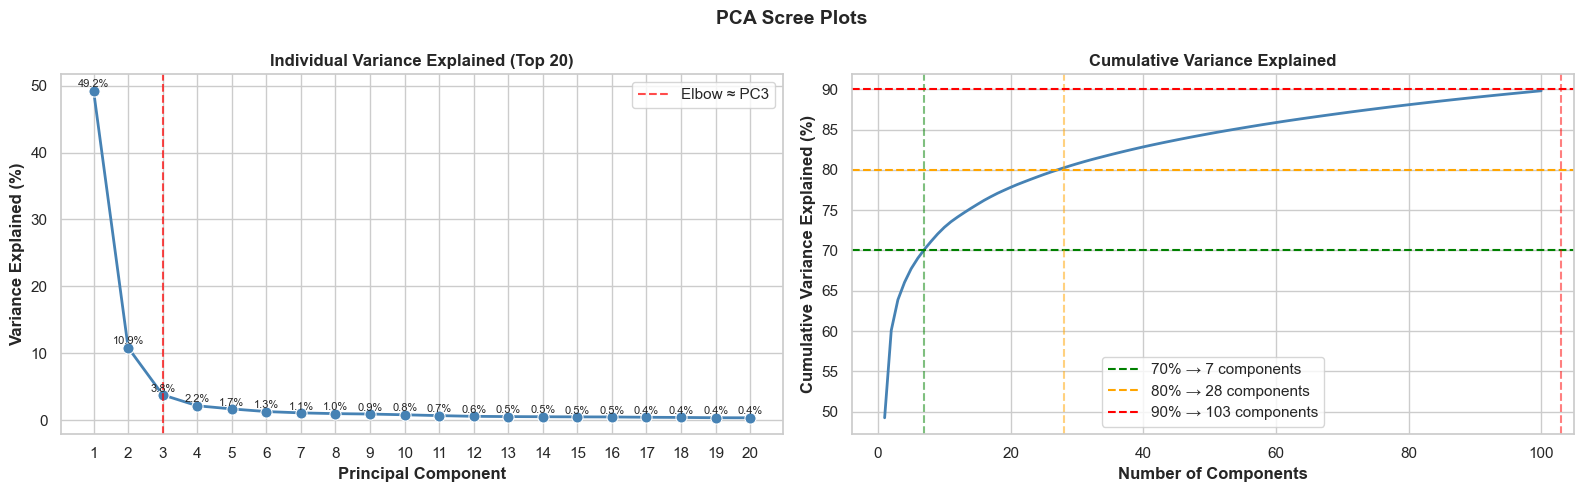

PC1: 49.23% variance explained
PC2: 10.85% variance explained
PC3: 3.80% variance explained
PC4: 2.17% variance explained
PC5: 1.69% variance explained


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCA Scree Plots', fontsize=14, fontweight='bold')

# --- Left: Zoomed scree plot with dots ---
sns.lineplot(x=range(1, 21), y=pca.explained_variance_ratio_[:20] * 100,
             marker='o', markersize=8, color='steelblue', linewidth=2, ax=axes[0])
for i, var in enumerate(pca.explained_variance_ratio_[:20] * 100, 1):
    axes[0].text(i, var + 0.5, f'{var:.1f}%', ha='center', fontsize=8)
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)', fontweight='bold')
axes[0].set_title('Individual Variance Explained (Top 20)', fontweight='bold')
axes[0].set_xticks(range(1, 21))
axes[0].axvline(3, color='red', linestyle='--', alpha=0.7, label='Elbow ≈ PC3')
axes[0].legend()

# --- Right: Cumulative variance ---
sns.lineplot(x=range(1, 101), y=cumvar[:100],
             color='steelblue', linewidth=2, ax=axes[1])
for threshold, color in zip([70, 80, 90], ['green', 'orange', 'red']):
    n = np.argmax(cumvar >= threshold) + 1
    axes[1].axhline(threshold, color=color, linestyle='--', label=f'{threshold}% → {n} components')
    axes[1].axvline(n, color=color, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print exact variance for first 5 components
for i, var in enumerate(pca.explained_variance_ratio_[:5] * 100, 1):
    print(f"PC{i}: {var:.2f}% variance explained")

The Scree plot to the right shows that PC1 (principal component 1) explains 49.3% of the variance alone. After PC3-4 it drops to nearly zero and becomes flat. Combining this with the cumulative variance plot to the righ, we will test the following values for number of principal components on LDA below: (1, 2, 7, 15, 20, 28, 50).

In [90]:
n_components_grid = [1, 2, 7, 15, 20, 28, 50]
pca_lda_results = []

for n in n_components_grid:
    # PCA
    pca_n = PCA(n_components=n)
    X_tr_pca = pca_n.fit_transform(X_tr_scaled)
    X_val_pca = pca_n.transform(X_val_scaled)
    
    # LDA
    lda_n = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    lda_n.fit(X_tr_pca, y_tr)
    
    train_acc = lda_n.score(X_tr_pca, y_tr) * 100
    val_acc = lda_n.score(X_val_pca, y_val) * 100
    
    # LUSC recall
    val_preds = lda_n.predict(X_val_pca)
    report = classification_report(y_val, val_preds, 
                                   target_names=['OV', 'LUSC', 'GBM'], 
                                   output_dict=True)
    lusc_recall = report['LUSC']['recall'] * 100
    
    pca_lda_results.append({
        'n_components': n,
        'Train Accuracy': round(train_acc, 2),
        'Val Accuracy': round(val_acc, 2),
        'LUSC Recall': round(lusc_recall, 2)
    })
    
    print(f"n={n:>3} | Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}% | LUSC Recall={lusc_recall:.2f}%")

# Summary table
pca_lda_df = pd.DataFrame(pca_lda_results)
print("\n PCA + LDA Results")
pca_lda_df

n=  1 | Train Acc=78.53% | Val Acc=82.58% | LUSC Recall=3.85%
n=  2 | Train Acc=86.58% | Val Acc=90.45% | LUSC Recall=57.69%
n=  7 | Train Acc=87.01% | Val Acc=89.89% | LUSC Recall=61.54%
n= 15 | Train Acc=87.01% | Val Acc=89.89% | LUSC Recall=61.54%
n= 20 | Train Acc=87.71% | Val Acc=89.33% | LUSC Recall=57.69%
n= 28 | Train Acc=87.71% | Val Acc=89.89% | LUSC Recall=61.54%
n= 50 | Train Acc=88.14% | Val Acc=88.76% | LUSC Recall=53.85%

 PCA + LDA Results


,n_components,Train Accuracy,Val Accuracy,LUSC Recall
0,1,78.53,82.58,3.85
1,2,86.58,90.45,57.69
2,7,87.01,89.89,61.54
3,15,87.01,89.89,61.54
4,20,87.71,89.33,57.69
5,28,87.71,89.89,61.54
6,50,88.14,88.76,53.85


PCA + LDA was evaluated across 7 values of n_components. Performance peaked at n=2 components for overall validation accuracy (90.45%), however n=7 components was selected as the final choice as it captures 70% of cumulative variance (consistent with the scree plot elbow), achieves higher LUSC recall (61.54%), and shows a smaller gap between training and validation accuracy suggesting better generalization.

Below we evaluate mislabeled detection again, this time with a threshold of 33%.

In [98]:
# Step 1: Fit final PCA + LDA with n=7
pca_final = PCA(n_components=7)
X_tr_pca_final = pca_final.fit_transform(X_tr_scaled)
X_val_pca_final = pca_final.transform(X_val_scaled)

# Step 2: Fit LDA
lda_final = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_final.fit(X_tr_pca_final, y_tr)

print(f"Train Accuracy: {lda_final.score(X_tr_pca_final, y_tr)*100:.2f}%")
print(f"Val Accuracy:   {lda_final.score(X_val_pca_final, y_val)*100:.2f}%")

# Step 3: Get class probabilities
train_probs = lda_final.predict_proba(X_tr_pca_final)
val_probs = lda_final.predict_proba(X_val_pca_final)

# Step 4: Self confidence for each sample
label_map = {1: 0, 2: 1, 3: 2}
y_tr_idx = np.array([label_map[l] for l in y_tr.values])
y_val_idx = np.array([label_map[l] for l in y_val.values])

train_self_conf = train_probs[np.arange(len(y_tr)), y_tr_idx]
val_self_conf = val_probs[np.arange(len(y_val)), y_val_idx]

# Step 5: Flag suspicious samples (threshold = 1/3)
threshold = 1/3  # random chance baseline for 3 classes

train_flagged = np.where(train_self_conf < threshold)[0]
val_flagged = np.where(val_self_conf < threshold)[0]

print(f"\nFlagged training samples:   {len(train_flagged)} ({len(train_flagged)/len(y_tr)*100:.1f}%)")
print(f"Flagged validation samples: {len(val_flagged)} ({len(val_flagged)/len(y_val)*100:.1f}%)")

# Step 6: Inspect flagged training samples
flagged_df = pd.DataFrame({
    'given_label': y_tr.values[train_flagged],
    'predicted_label': lda_final.predict(X_tr_pca_final[train_flagged]),
    'self_confidence': train_self_conf[train_flagged].round(4)
})
flagged_df['given_label_name'] = flagged_df['given_label'].map({1:'OV', 2:'LUSC', 3:'GBM'})
flagged_df['predicted_label_name'] = flagged_df['predicted_label'].map({1:'OV', 2:'LUSC', 3:'GBM'})
flagged_df = flagged_df.sort_values('self_confidence').reset_index(drop=True)

print("\nMost suspicious training samples:")
print(flagged_df.head(20))

# Step 7: Summary of suspected label flips
print("\nSummary of suspected label flips (training):")
print(pd.crosstab(flagged_df['given_label_name'],
                  flagged_df['predicted_label_name'],
                  rownames=['Given Label'],
                  colnames=['Suspected True Label']))

# Step 8: Full classification report
print("\nPCA + LDA Validation Classification Report:")
print(classification_report(y_val, lda_final.predict(X_val_pca_final),
                            target_names=['OV', 'LUSC', 'GBM']))

Train Accuracy: 87.01%
Val Accuracy:   89.89%

Flagged training samples:   92 (13.0%)
Flagged validation samples: 17 (9.6%)

Most suspicious training samples:
    given_label  predicted_label  self_confidence given_label_name  \
0             1                2           0.0001               OV   
1             1                2           0.0001               OV   
2             3                2           0.0002              GBM   
3             2                3           0.0003             LUSC   
4             1                2           0.0003               OV   
5             2                3           0.0003             LUSC   
6             2                3           0.0005             LUSC   
7             3                1           0.0005              GBM   
8             2                3           0.0005             LUSC   
9             2                3           0.0006             LUSC   
10            1                2           0.0006               OV   
1

Surprisingly, PCA+LDA with 7 principal components is quite competitive. It flagged 92 training samples (13%), which is much more consistent with Cleanlab's 70 (9.9%) than the regularized LDA alone. We also observe a training accuracy of 87%, and a validation accuracy of 89%, suggesting that PCA fixed the overconfidence problem. Additionally, we observe LUSC is the key problem here (consistent with Cleanlab): 37 samples are suspected to actually be LUSC, but are labeled as something else.

Quick comparison between Random Forest and LDA+PCA (k=7).

In [110]:
model_comparison = pd.DataFrame({
    'Metric': ['Val Accuracy', 'LUSC Recall', 'OV Recall', 'GBM Recall'],
    'Random Forest': ['91.01%', '61.54%', '97.14%', '95.12%'],
    'PCA + LDA (n=7)': ['89.89%', '61.54%', '94.29%', '95.12%']
})

model_comparison

,Metric,Random Forest,PCA + LDA (n=7)
0,Val Accuracy,91.01%,89.89%
1,LUSC Recall,61.54%,61.54%
2,OV Recall,97.14%,94.29%
3,GBM Recall,95.12%,95.12%


Comparison of mislabeled observations: Cleanlab vs PCA-LDA

In [106]:
cleanlab_flagged = set(y_tr.index[label_issues_idx])
pca_lda_flagged = set(y_tr.index[train_flagged])

overlap = cleanlab_flagged & pca_lda_flagged
print(f"Cleanlab flagged:      {len(cleanlab_flagged)} samples")
print(f"PCA+LDA flagged:       {len(pca_lda_flagged)} samples")
print(f"Overlap (both agree):  {len(overlap)} samples")
print(f"Only Cleanlab:         {len(cleanlab_flagged - pca_lda_flagged)} samples")
print(f"Only PCA+LDA:          {len(pca_lda_flagged - cleanlab_flagged)} samples")

Cleanlab flagged:      70 samples
PCA+LDA flagged:       92 samples
Overlap (both agree):  70 samples
Only Cleanlab:         0 samples
Only PCA+LDA:          22 samples


Both methods agree on the core of mislabeled observations: Every single sample Cleanlab flagged was also flagged by PCA+LDA, meaning that we have confirmed these samples using an independent method (not built-in). PCA+LDA found 22 additional suspicious samples that Cleanlab missed, but overall, we find really good agreement across methods. The 22 samples not identified by Cleanlab, may represent borderline cases. The agreement between two fundamentally different approaches — one based on Random Forest OOB probabilities and the other on a probabilistic linear discriminant model — substantially strengthens our confidence in the mislabeled sample identification.

## Pipeline 3: Boosting

Our goal now is to improve prediction accuracy by using a more complex technique: Boosting. But before that, some notes on other approaches that were considered:
+ Regularized logistic regression (L1/L2) was considered but not pursued as it assumes a linear decision boundary and is less suited to high-dimensional gene expression data where interactions between genes are likely important. We believe it would have a similar or worse performance than LDA since the data is likely separable.
+ SVMs were also considered but are computationally expensive for high-dimensional data with 1000 features and 886 samples, and offer less interpretability than Random Forest in terms of feature importance.

To implement Gradient Boosting as a second tree ensemble method, we follow Algorithm 8.2 from James et al. (2021). Unlike Random Forest where trees are grown independently in parallel, boosting builds trees sequentially. 

Procedure:

The key tuning parameters are:
+ **B**: number of trees
+ **λ**: learning rate/shrinkage)
+ **d**: tree depth. 

Citation:
James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning (2nd ed.). Springer.

In [120]:
# Libraries:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

We start by finding the best learning rate and tree depth using CV, fixing B=1000 for tuning speed. Then, we will find the best B.

In [128]:
# Step 1: Define tuning grid
learning_rates = [0.001, 0.01, 0.1, 0.2]
max_depths = [1, 2, 3, 4]

tuning_results_boost = []

# Step 2: Tuning loop
for lr, depth in itertools.product(learning_rates, max_depths):
    boost = GradientBoostingClassifier(
        n_estimators=1000,  # fixed for tuning speed
        learning_rate=lr,
        max_depth=depth,
        random_state=42
    )
    boost.fit(X_tr_clean, y_tr_clean)
    
    val_preds = boost.predict(X_val_filtered)
    val_acc = accuracy_score(y_val, val_preds) * 100
    
    # LUSC recall
    report = classification_report(y_val, val_preds,
                                   target_names=['OV', 'LUSC', 'GBM'],
                                   output_dict=True)
    lusc_recall = report['LUSC']['recall'] * 100
    
    tuning_results_boost.append({
        'learning_rate': lr,
        'max_depth': depth,
        'Val Accuracy': round(val_acc, 2),
        'LUSC Recall': round(lusc_recall, 2)
    })
    
    print(f"lr={lr:.3f} | depth={depth} | Val Acc={val_acc:.2f}% | LUSC Recall={lusc_recall:.2f}%")

# Step 3: Results table
boost_tuning_df = pd.DataFrame(tuning_results_boost).sort_values(
    'Val Accuracy', ascending=False).reset_index(drop=True)
print("\n--- Boosting Tuning Results (sorted by Val Accuracy) ---")
print(boost_tuning_df)

# Step 4: Best parameters
best_boost_params = boost_tuning_df.iloc[0]
print(f"\nBest: lr={best_boost_params['learning_rate']} | depth={int(best_boost_params['max_depth'])} | Val Acc={best_boost_params['Val Accuracy']}%")

lr=0.001 | depth=1 | Val Acc=90.45% | LUSC Recall=57.69%
lr=0.001 | depth=2 | Val Acc=90.45% | LUSC Recall=57.69%
lr=0.001 | depth=3 | Val Acc=90.45% | LUSC Recall=57.69%
lr=0.001 | depth=4 | Val Acc=90.45% | LUSC Recall=57.69%
lr=0.010 | depth=1 | Val Acc=91.57% | LUSC Recall=65.38%
lr=0.010 | depth=2 | Val Acc=92.13% | LUSC Recall=69.23%
lr=0.010 | depth=3 | Val Acc=90.45% | LUSC Recall=61.54%
lr=0.010 | depth=4 | Val Acc=89.89% | LUSC Recall=57.69%
lr=0.100 | depth=1 | Val Acc=91.01% | LUSC Recall=65.38%
lr=0.100 | depth=2 | Val Acc=92.13% | LUSC Recall=69.23%
lr=0.100 | depth=3 | Val Acc=91.01% | LUSC Recall=61.54%
lr=0.100 | depth=4 | Val Acc=90.45% | LUSC Recall=57.69%
lr=0.200 | depth=1 | Val Acc=91.57% | LUSC Recall=69.23%
lr=0.200 | depth=2 | Val Acc=91.57% | LUSC Recall=69.23%
lr=0.200 | depth=3 | Val Acc=90.45% | LUSC Recall=61.54%
lr=0.200 | depth=4 | Val Acc=90.45% | LUSC Recall=57.69%

--- Boosting Tuning Results (sorted by Val Accuracy) ---
    learning_rate  max_depth  

The selected parameters are learning rate 0.1 and depth 2 (yield same accuracy as 0.01 and will take less time to run). Next, we select the value of B. Note that this model was tuned using the full training dataset without removing suspicious observations. Since we selected learning rate of 0.1, B = 500-1000 is good as per ISL. Hence, we will use B=1000 for the final model. This is also backed up by Alvarez-Uriarte paper.

In [ ]:
# Final Boosting Model
boost_final = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)
boost_final.fit(X_tr_clean, y_tr_clean)

val_preds_boost = boost_final.predict(X_val_filtered)
print("\nGradient Boosting Validation Classification Report:")
print(classification_report(y_val, val_preds_boost,
                            target_names=['OV', 'LUSC', 'GBM']))

In [135]:
from xgboost import XGBClassifier

boost_final = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=2,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1  # parallelized!
)

# XGBoost needs 0-indexed labels
boost_final.fit(X_tr_clean, y_tr_clean - 1)

val_preds_boost = boost_final.predict(X_val_filtered) + 1  # back to 1-indexed

print("\nXGBoost Validation Classification Report:")
print(classification_report(y_val, val_preds_boost,
                            target_names=['OV', 'LUSC', 'GBM']))


XGBoost Validation Classification Report:
              precision    recall  f1-score   support

          OV       0.91      0.97      0.94        70
        LUSC       0.94      0.65      0.77        26
         GBM       0.92      0.95      0.93        82

    accuracy                           0.92       178
   macro avg       0.92      0.86      0.88       178
weighted avg       0.92      0.92      0.91       178



We decided to run the model with the same parameters using XGBoost instead, as the other one was taking 10+ minutes to run.

Note that we used XGBoost (Chen & Guestrin, 2016), an optimized implementation of gradient boosting that adds L1/L2 regularization and parallelization, making it significantly faster while following the same core Algorithm 8.2."

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. ACM SIGKDD, 785–794.

In [138]:
final_comparison = pd.DataFrame({
    'Metric': ['Val Accuracy', 'LUSC Recall', 'OV Recall', 'GBM Recall'],
    'Random Forest': ['91.01%', '61.54%', '97.14%', '95.12%'],
    'PCA + LDA (n=7)': ['89.89%', '61.54%', '94.29%', '95.12%'],
    'XGBoost': ['92.13%', '65.38%', '97.14%', '95.12%']
})

final_comparison

,Metric,Random Forest,PCA + LDA (n=7),XGBoost
0,Val Accuracy,91.01%,89.89%,92.13%
1,LUSC Recall,61.54%,61.54%,65.38%
2,OV Recall,97.14%,94.29%,97.14%
3,GBM Recall,95.12%,95.12%,95.12%


XGBoost outperformed both Random Forest and PCA+LDA across all metrics, achieving 92.13% validation accuracy and 65.38% LUSC recall. Notably, this evaluation was conducted on the full validation set including potentially mislabeled observations, meaning the true performance on clean data is likely even higher. The improvement in LUSC recall is particularly notable given the class imbalance and suspected label noise in this minority class, suggesting that XGBoost's regularization makes it inherently more robust to label noise than Random Forest.

Finally, we attempt something similar to what we did with Random Forest: we fit the model to the data without suspicious observations, and predict on the validation set without removing any observations from it. Let's see if the result is the same as with random forest.

In [157]:
# Step 1: Fit XGBoost on cleaned training data only
boost_clean = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=2,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
boost_clean.fit(X_tr_clean, y_tr_clean - 1)
print("XGBoost fitted on cleaned training data!")

# Step 2: Predict on FULL validation set (including suspicious observations)
val_preds_clean_boost = boost_clean.predict(X_val_filtered.values) + 1

print("\nXGBoost (cleaned train, full val) Classification Report:")
print(classification_report(y_val, val_preds_clean_boost,
                            target_names=['OV', 'LUSC', 'GBM']))

print("\nConfusion Matrix:")
print(pd.crosstab(y_val, val_preds_clean_boost,
                  rownames=['Actual'], colnames=['Predicted']))

XGBoost fitted on cleaned training data!

XGBoost (cleaned train, full val) Classification Report:
              precision    recall  f1-score   support

          OV       0.91      0.97      0.94        70
        LUSC       0.94      0.65      0.77        26
         GBM       0.92      0.95      0.93        82

    accuracy                           0.92       178
   macro avg       0.92      0.86      0.88       178
weighted avg       0.92      0.92      0.91       178


Confusion Matrix:
Predicted   1   2   3
Actual               
1          68   1   1
2           3  17   6
3           4   0  78


XGBoost trained on cleaned data and evaluated on the full validation set — including potentially mislabeled observations — achieved 92.13% accuracy and 65.38% LUSC recall, outperforming both Random Forest (91.01%, 61.54%) and PCA+LDA (89.89%, 61.54%). Consistent with our Random Forest findings, removing suspicious observations from the training set did not dramatically change validation performance, further confirming that ensemble tree methods are inherently robust to label noise.

## Final Predictions + Kaggle Submission

We submitted several predictions but the three top ones include:
+ **Random Forest** with mtry = 75 and nodesize = 1 → Test Accuracy: 100%
+ **Random Forest** with mtry = 75 and nodesize = 1 (fitted without suspicious observations) → Test accuracy: 100%
+ **XG Boost** with learning rate 0.1, depth 2, B=1000  → Test accuracy: 99.44%

A few notes about how we submitted our prediction: We check and found a label in the training set did not match the test set, likely because Excel read this as a date when the data was opened first. We had to change a label in the test set to make them match. Additionally, all models were fitted on the entire dataset (training + validation) to benefit from having a larger training sample size (886 rather than 708), before predicting on the test set.

In [170]:
# Check that training and test data have the same columns
print("Problematic genes in top_genes not found in test:")
missing = [g for g in top_genes if g not in X_test.columns]
print(missing)

print("\nColumns in test that look like dates:")
date_like = [c for c in X_test.columns if 'Mar' in str(c) or 'Sep' in str(c) or 'Dec' in str(c)]
print(date_like)

Problematic genes in top_genes not found in test:
['03-Mar']

Columns in test that look like dates:
[]


In [189]:
# Step 1: Fix Excel date corruption in test set
march_rename = {
    'MARCH2': '02-Mar',
    'MARCH3': '03-Mar',
    'MARCH5': '05-Mar',
    'MARCH6': '06-Mar',
    'MARCH7': '07-Mar'
}
test = test.rename(columns=march_rename)
print("Step 1 done: Excel date corruption fixed!")

# Step 2: Prepare test set
X_test = test.drop(columns=['id'])
X_test_filtered = X_test[top_genes]
print(f"Step 2 done: Test set prepared → {X_test_filtered.shape}")

Step 1 done: Excel date corruption fixed!
Step 2 done: Test set prepared → (379, 1000)


In [195]:
# Double check that names match
train_genes = set(X_train.drop(columns=['cancer'], errors='ignore').columns)
test_genes = set(test.drop(columns=['id']).columns)

print(f"Genes in train: {len(train_genes)}")
print(f"Genes in test:  {len(test_genes)}")
print(f"In train but not test: {train_genes - test_genes}")
print(f"In test but not train: {test_genes - train_genes}")

Genes in train: 12042
Genes in test:  12042
In train but not test: {'04-Sep', '07-Sep', '15-Sep', '02-Sep', '09-Sep', '01-Dec', '10-Sep', '06-Sep', '11-Sep', '08-Sep'}
In test but not train: {'SEPT8', 'SEPT2', 'SEPT7', 'SEPT11', 'SEP15', 'SEPT9', 'DEC1', 'SEPT4', 'SEPT6', 'SEPT10'}


In [197]:
# Fix ALL Excel date corruption in test set
date_rename = {
    'MARCH2': '02-Mar',
    'MARCH3': '03-Mar',
    'MARCH5': '05-Mar',
    'MARCH6': '06-Mar',
    'MARCH7': '07-Mar',
    'SEPT2':  '02-Sep',
    'SEPT4':  '04-Sep',
    'SEPT6':  '06-Sep',
    'SEPT7':  '07-Sep',
    'SEPT8':  '08-Sep',
    'SEPT9':  '09-Sep',
    'SEPT10': '10-Sep',
    'SEPT11': '11-Sep',
    'SEP15':  '15-Sep',
    'DEC1':   '01-Dec'
}

test = test.rename(columns=date_rename)

# Verify
train_genes = set(X_train.columns)
test_genes = set(test.drop(columns=['id']).columns)
print(f"Remaining mismatches: {train_genes - test_genes}")

Remaining mismatches: set()


In [199]:
# Double check that names match
train_genes = set(X_train.drop(columns=['cancer'], errors='ignore').columns)
test_genes = set(test.drop(columns=['id']).columns)

print(f"Genes in train: {len(train_genes)}")
print(f"Genes in test:  {len(test_genes)}")
print(f"In train but not test: {train_genes - test_genes}")
print(f"In test but not train: {test_genes - train_genes}")

Genes in train: 12042
Genes in test:  12042
In train but not test: set()
In test but not train: set()


In [204]:
# Prepare datasets:

# Clean test set
X_test = test.drop(columns=['id'])
X_test_filtered = X_test[top_genes]
print(f"Step 2 done: Test set prepared → {X_test_filtered.shape}")

# Clean validation set remove suspicous observations from validation set only
all_val_indices = np.arange(len(y_val))
clean_val_mask = ~np.isin(all_val_indices, label_issues_val)
X_val_clean = X_val_filtered[clean_val_mask]
y_val_clean = y_val.values[clean_val_mask]
print(f"Step 3 done: Val set cleaned → {len(y_val_clean)} samples (removed {len(y_val) - len(y_val_clean)})")

Step 2 done: Test set prepared → (379, 1000)
Step 3 done: Val set cleaned → 167 samples (removed 11)


In [206]:
# Random Forest Submission: On cleaned data with no suspicious observations

# Combine cleaned tr + cleaned val
X_all_clean = np.vstack([X_tr_clean, X_val_clean])
y_all_clean = np.concatenate([y_tr_clean, y_val_clean])
print(f"\nSubmission 2 data: {X_all_clean.shape}")

rf_kaggle_clean = RandomForestClassifier(
    n_estimators=1000,
    max_features=75,
    min_samples_leaf=1,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_kaggle_clean.fit(X_all_clean, y_all_clean)
print("Submission 2: RF fitted on cleaned data!")

test_preds_rf_clean = rf_kaggle_clean.predict(X_test_filtered.values)

submission_rf_clean = pd.DataFrame({
    'id': test['id'],
    'cancer': test_preds_rf_clean
})
print("Prediction distribution:")
print(submission_rf_clean['cancer'].value_counts().sort_index())
submission_rf_clean.to_csv('submission_rf_clean.csv', index=False)
print("Submission 2 saved!")


Submission 2 data: (805, 1000)
Submission 2: RF fitted on cleaned data!
Prediction distribution:
cancer
1    163
2     43
3    173
Name: count, dtype: int64
Submission 2 saved!


In [208]:
# XGBoost Submission (all observations, no cleaning)

# Combine ALL tr + ALL val (no cleaning)
X_all_full = np.vstack([X_tr_filtered.values, X_val_filtered.values])
y_all_full = np.concatenate([y_tr.values, y_val.values])
print(f"\nSubmission 3 data: {X_all_full.shape}")

boost_kaggle = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=2,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
boost_kaggle.fit(X_all_full, y_all_full - 1)  # 0-indexed
print("Submission 3: XGBoost fitted on all data!")

test_preds_xgb = boost_kaggle.predict(X_test_filtered.values) + 1  # back to 1-indexed

submission_xgb = pd.DataFrame({
    'id': test['id'],
    'cancer': test_preds_xgb
})
print("Prediction distribution:")
print(submission_xgb['cancer'].value_counts().sort_index())
submission_xgb.to_csv('submission_xgb.csv', index=False)
print("Submission 3 saved!")


Submission 3 data: (886, 1000)
Submission 3: XGBoost fitted on all data!
Prediction distribution:
cancer
1    161
2     43
3    175
Name: count, dtype: int64
Submission 3 saved!


Below are the prediction results from our top 3 models in Kaggle:

In [216]:
kaggle_results = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest (cleaned)', 'XGBoost'],
    'Test Accuracy': ['100%', '100%', '99.44%']
})

kaggle_results

,Model,Test Accuracy
0,Random Forest,100%
1,Random Forest (cleaned),100%
2,XGBoost,99.44%


Both RF and XGB predicted the same number of LUSC samples (43)in the test data, however RF predicted two samples as GBM, that XGBoost predicted as OV. These were likely incorrect as observed by the difference in accuracies (XGBoost had a lower one), however we still need to to wait for results on the other 53% of the data.

## Visualizations!!

In [224]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

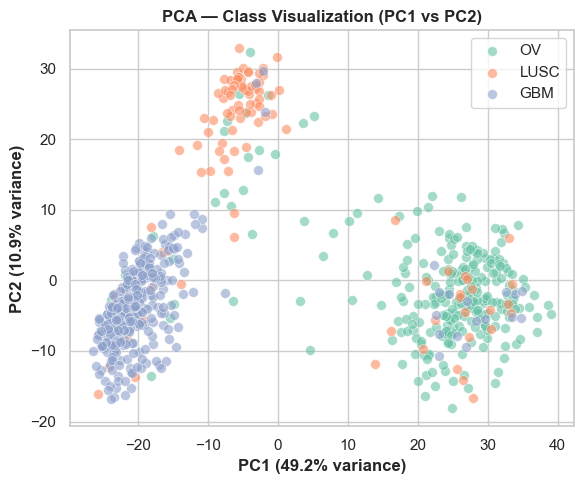

In [288]:
plt.figure(figsize=(6, 5))
pca_viz = PCA(n_components=2)
X_tr_pca_viz = pca_viz.fit_transform(X_tr_scaled)

colors = {1: '#66c2a5', 2: '#fc8d62', 3: '#8da0cb'}
label_names = {1: 'OV', 2: 'LUSC', 3: 'GBM'}

for label in [1, 2, 3]:
    mask = y_tr.values == label
    plt.scatter(X_tr_pca_viz[mask, 0], X_tr_pca_viz[mask, 1],
                c=colors[label], label=label_names[label],
                alpha=0.6, edgecolors='white', linewidth=0.5, s=50)

plt.title('PCA — Class Visualization (PC1 vs PC2)', fontweight='bold')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

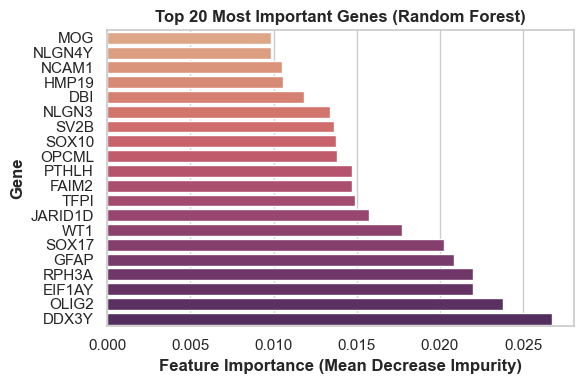

In [284]:
plt.figure(figsize=(6, 4))
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=top_genes
).nlargest(20).sort_values()

sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='flare')
plt.title('Top 20 Most Important Genes (Random Forest)', fontweight='bold')
plt.xlabel('Feature Importance (Mean Decrease Impurity)', fontweight='bold')
plt.ylabel('Gene', fontweight='bold')
plt.tight_layout()
plt.show()

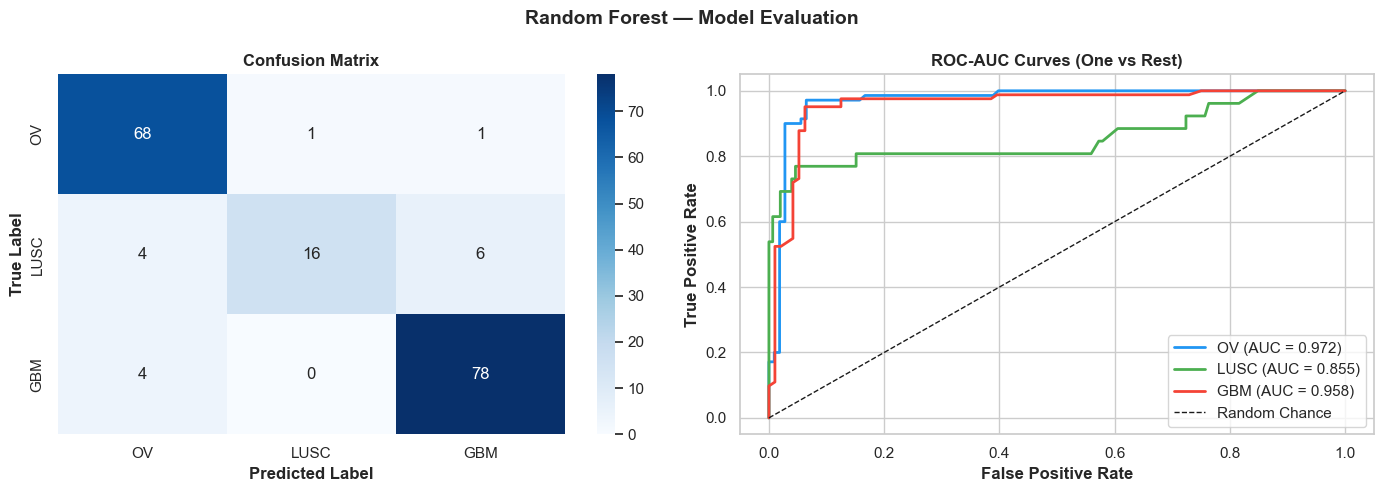

In [234]:
y_val_bin = label_binarize(y_val, classes=[1, 2, 3])
val_probs_rf = best_rf.predict_proba(X_val_filtered)
val_preds_rf = best_rf.predict(X_val_filtered)
colors_roc = ['#2196F3', '#4CAF50', '#F44336']
class_names = ['OV', 'LUSC', 'GBM']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm_rf = confusion_matrix(y_val, val_preds_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# ROC-AUC
for i, (color, name) in enumerate(zip(colors_roc, class_names)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], val_probs_rf[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Chance')
axes[1].set_title('ROC-AUC Curves (One vs Rest)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

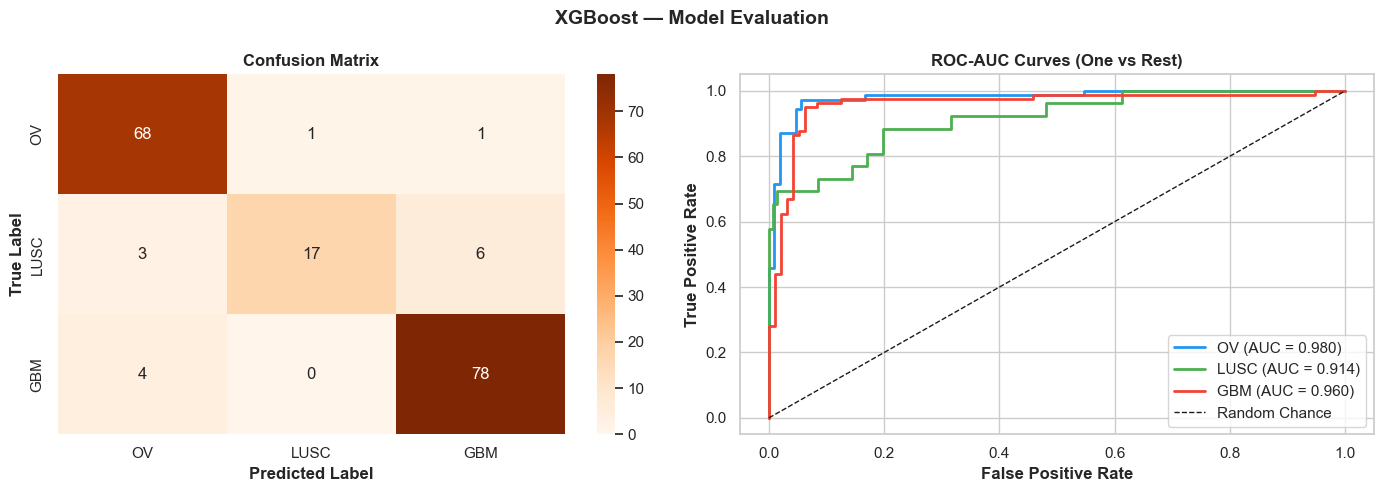

In [236]:
val_probs_xgb = boost_clean.predict_proba(X_val_filtered.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost — Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm_xgb = confusion_matrix(y_val, val_preds_clean_boost)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# ROC-AUC
for i, (color, name) in enumerate(zip(colors_roc, class_names)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], val_probs_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Chance')
axes[1].set_title('ROC-AUC Curves (One vs Rest)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

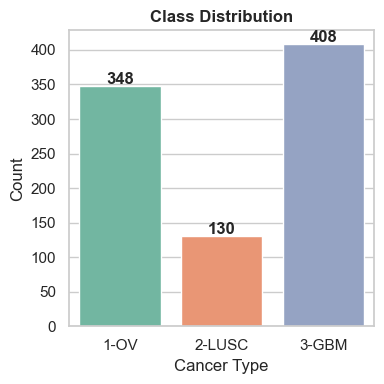

In [282]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(4, 4))

label_map = {1: '1-OV', 2: '2-LUSC', 3: '3-GBM'}
class_counts = y_train.value_counts().sort_index().reset_index()
class_counts.columns = ['Cancer Type', 'Count']
class_counts['Cancer Type'] = class_counts['Cancer Type'].map(label_map)

sns.barplot(data=class_counts, x='Cancer Type', y='Count', palette='Set2')
plt.title('Class Distribution', fontweight='bold')
for i, val in enumerate(class_counts['Count']):
    plt.text(i, val + 3, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

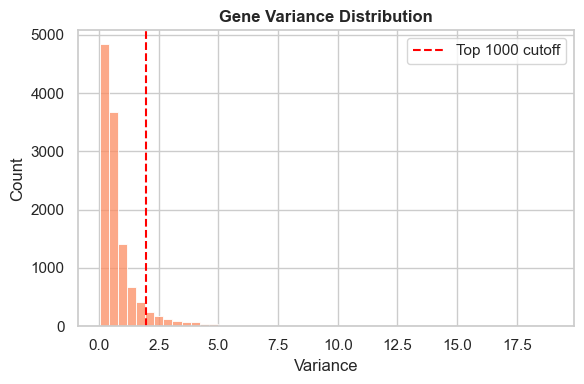

In [274]:
plt.figure(figsize=(6, 4))

sns.histplot(gene_variances, bins=50, color=sns.color_palette('Set2')[1])
plt.title('Gene Variance Distribution', fontweight='bold')
plt.xlabel('Variance')
plt.axvline(gene_variances.nlargest(1000).min(), color='red', linestyle='--', label='Top 1000 cutoff')
plt.legend()
plt.tight_layout()
plt.show()

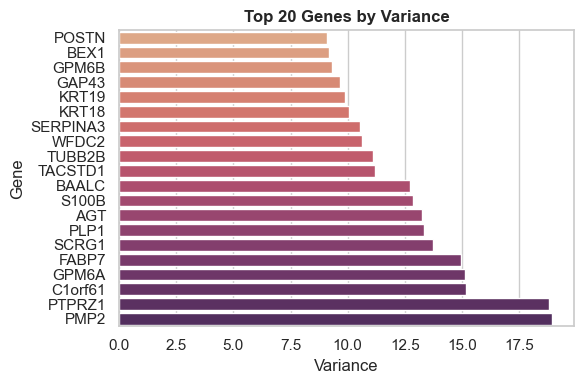

In [272]:
plt.figure(figsize=(6, 4))

top20 = gene_variances.nlargest(20).sort_values().reset_index()
top20.columns = ['Gene', 'Variance']

sns.barplot(data=top20, x='Variance', y='Gene', palette='flare')
plt.title('Top 20 Genes by Variance', fontweight='bold')
plt.tight_layout()
plt.show()